In [3]:
from google.colab import auth
auth.authenticate_user()


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading private GCS files
customers = pd.read_csv("gs://ppnj_data/files/dim_customer.csv")
travel_package = pd.read_csv("gs://ppnj_data/files/dim_travel_package.csv")
sales = pd.read_csv("gs://ppnj_data/files/fact_sales.csv")
travel_guide = pd.read_csv("gs://ppnj_data/files/dim_travel_guide.csv")
feedback = pd.read_csv("gs://ppnj_data/files/dim_feedback.csv")
refund = pd.read_csv("gs://ppnj_data/files/dim_refund.csv")


## Overview

In [5]:
# checking data
customers.info()
travel_package.info()
sales.info()
feedback.info()
refund.info()

# Preview
customers.head()
sales.sample(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    1234 non-null   object
 1   customer_name  1234 non-null   object
 2   gender         1234 non-null   object
 3   age            1234 non-null   int64 
 4   email          1234 non-null   object
 5   customer_type  1234 non-null   object
dtypes: int64(1), object(5)
memory usage: 58.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   package_id     39 non-null     object
 1   package_name   39 non-null     object
 2   package_type   39 non-null     object
 3   duration_days  39 non-null     int64 
 4   price_per_pax  39 non-null     int64 
 5   category       39 non-null     object
 6   destination    39 non-null     object
dtypes: in

,booking_id,customer_id,package_id,guide_id,booking_date,travel_date,num_of_pax,discount_promotion,channel,payment_status,payment_method
603,BK703,MY1110,PC35,105,2023-04-23,2023-05-08,1,91,agent,paid,cash
903,BK1003,MY1067,PC46,105,2023-08-04,2023-08-06,3,0,walk in,paid,cash
707,BK807,MY2149,PC48,104,2023-11-03,2023-11-09,2,0,walk in,paid,credit card
642,BK742,MY1152,PC38,101,2023-08-20,2023-09-10,4,953,online,paid,eWallet
336,BK436,MY1012,PC18,106,2023-12-09,2023-12-24,16,0,agent,paid,cash


## Null Checks & Duplicates

In [6]:
# Checking for nulls

for name, df in {'Customers': customers, 'Sales': sales, 'Feedback': feedback, 'Refund': refund}.items():
    print(f"\n{name} missing values:")
    print(df.isnull().sum())

# Checking for duplicate booking_id or customer_id
print("Duplicate booking_id:", sales.duplicated('booking_id').sum())
print("Duplicate customer_id:", customers.duplicated('customer_id').sum())



Customers missing values:
customer_id      0
customer_name    0
gender           0
age              0
email            0
customer_type    0
dtype: int64

Sales missing values:
booking_id            0
customer_id           0
package_id            0
guide_id              0
booking_date          0
travel_date           0
num_of_pax            0
discount_promotion    0
channel               0
payment_status        0
payment_method        0
dtype: int64

Feedback missing values:
feedback_id           0
package_id            0
booking_id            0
satisfaction_score    0
feedback_date         0
comments              0
rating_hotel          0
rating_guide          0
rating_itinerary      0
would_recommend       0
dtype: int64

Refund missing values:
refund_id            0
booking_id           0
customer_id          0
refund_date          0
refund_amount        0
refund_percentage    0
reason               0
refund_status        0
dtype: int64
Duplicate booking_id: 0
Duplicate customer_id:

## Key Distributions

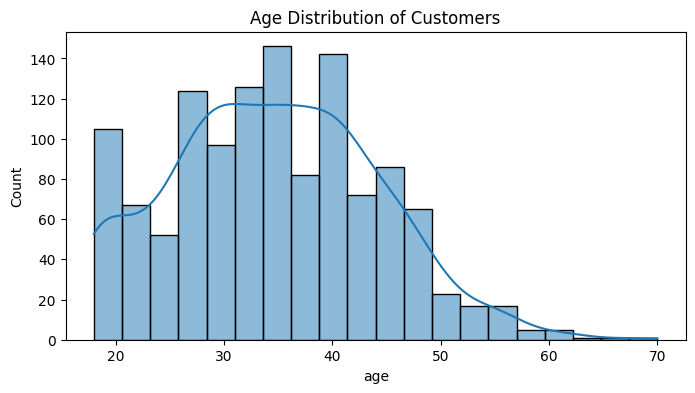

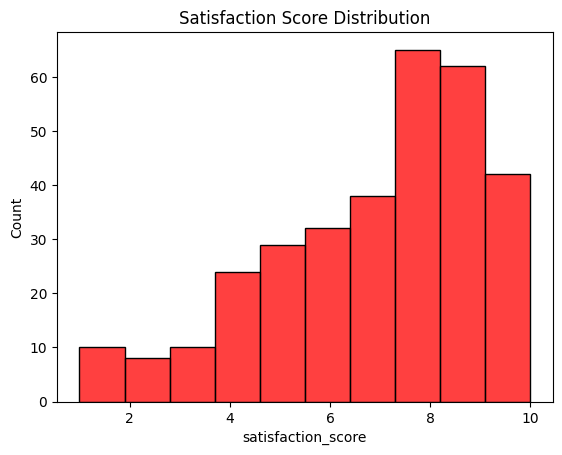

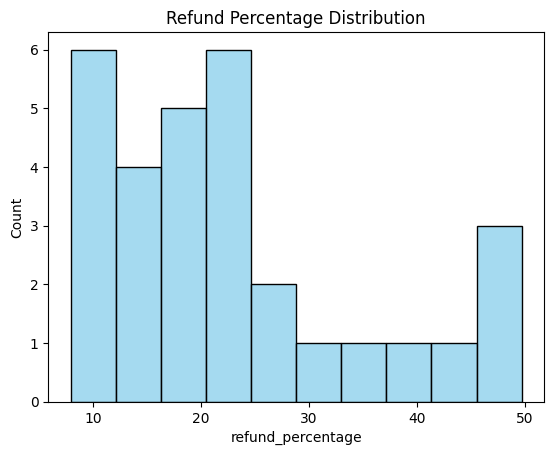

In [7]:
# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(customers['age'], kde=True, bins=20)
plt.title("Age Distribution of Customers")
plt.show()

# Satisfaction score
sns.histplot(feedback['satisfaction_score'], bins=10, color='red')
plt.title("Satisfaction Score Distribution")
plt.show()

# Refund %
sns.histplot(refund['refund_percentage'], bins=10, color='skyblue')
plt.title("Refund Percentage Distribution")
plt.show()


## Business Logic Checks

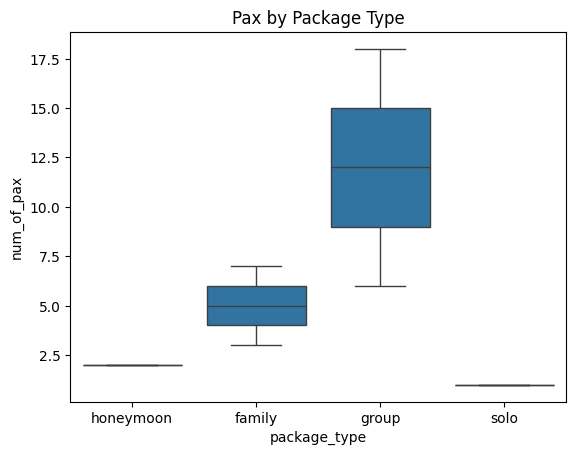

Refund outliers (amount > total trip value): 0


In [8]:
# num_of_pax vs package_type
merged = sales.merge(travel_package[['package_id', 'package_type']], on='package_id')
sns.boxplot(x='package_type', y='num_of_pax', data=merged)
plt.title("Pax by Package Type")
plt.show()

# Check if any refunds have amount > total price
merged_refund = refund.merge(sales[['booking_id', 'package_id', 'num_of_pax']], on='booking_id')
merged_refund = merged_refund.merge(travel_package[['package_id', 'price_per_pax']], on='package_id')
merged_refund['expected_price'] = merged_refund['price_per_pax'] * merged_refund['num_of_pax']
merged_refund['is_outlier'] = merged_refund['refund_amount'] > merged_refund['expected_price']
print("Refund outliers (amount > total trip value):", merged_refund['is_outlier'].sum())


## Relationships

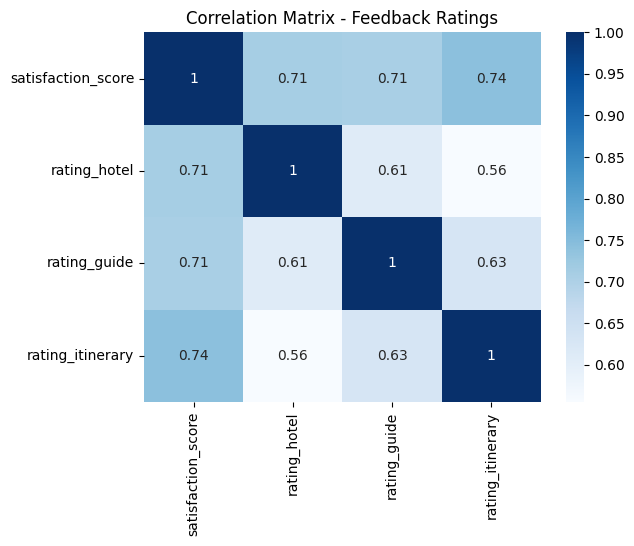

In [9]:
# Correlation on numeric feedback data
numeric_feedback = feedback[['satisfaction_score', 'rating_hotel', 'rating_guide', 'rating_itinerary']]
sns.heatmap(numeric_feedback.corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix - Feedback Ratings")
plt.show()


## Grouped Insights

In [10]:
# Avg satisfaction by guide
merged_feedback = feedback.merge(sales[['booking_id', 'guide_id']], on='booking_id')
guide_scores = merged_feedback.groupby('guide_id', as_index=False)['satisfaction_score'].mean()
guide_scored_name = guide_scores.merge(travel_guide[['staff_id','staff_name']], left_on='guide_id', right_on='staff_id')
guide_finalize = guide_scored_name.drop(columns='staff_id')
print(f"Average Satisfaction Score by Guide:\n {guide_finalize}")

# Top refund reasons
print("Refund Reasons:\n", refund['reason'].value_counts())


Average Satisfaction Score by Guide:
    guide_id  satisfaction_score staff_name
0       101            7.468085     Nasrul
1       102            6.888889      Khair
2       103            7.324324      Intan
3       104            6.593750      Amira
4       105            7.206897       Nuha
5       106            7.054054     Alissa
6       107            7.375000     Waddah
7       108            6.580645      Izzah
8       109            6.625000      Nasir
Refund Reasons:
 reason
Other                       7
Unforeseen circumstances    5
Health emergencies          5
Cancellation by customer    4
Travel restrictions         3
Natural disasters           2
Service quality issues      2
Package change request      2
Name: count, dtype: int64
